# Can you implement linear regression, though?

_Ok, so this might sound like a silly activity but it can actually be fun to implement linear regression from scratch and showcase some basic numerical analysis while we're at it_

In [1]:
! pip install kagglehub

In [2]:
## Let's download the Kaggle salary dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hussainnasirkhan/multiple-linear-regression-dataset")

print("Path to dataset files:", path)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/ethanhersch/.cache/kagglehub/datasets/hussainnasirkhan/multiple-linear-regression-dataset/versions/1


In [3]:
import os
import pandas as pd

csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

df = pd.read_csv(csv_files[0])

In [4]:
df

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


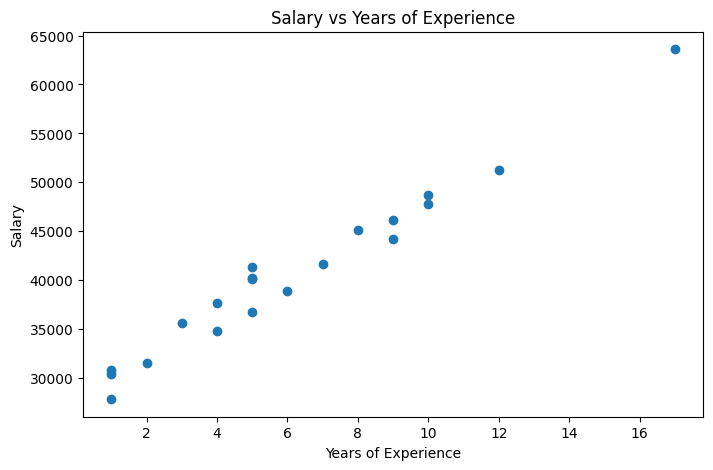

In [5]:
import matplotlib.pyplot as plt
# Scatter plot: YearsExperience vs Salary
plt.figure(figsize=(8, 5))
plt.scatter(df['experience'], df['income'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.show()

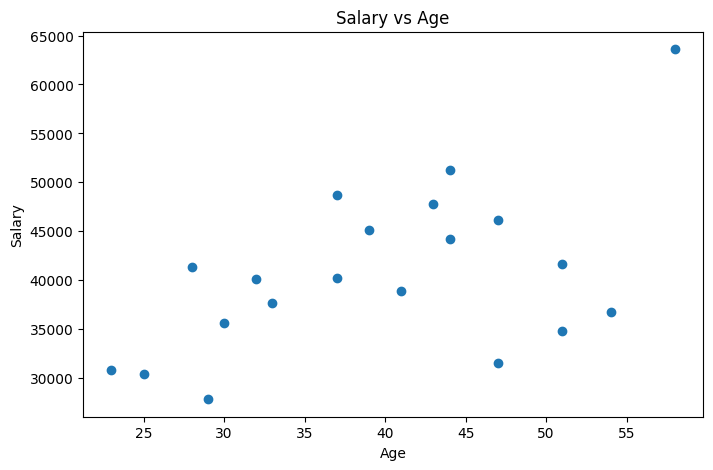

In [6]:
import matplotlib.pyplot as plt
# Scatter plot: YearsExperience vs Salary
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['income'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Salary vs Age')
plt.show()

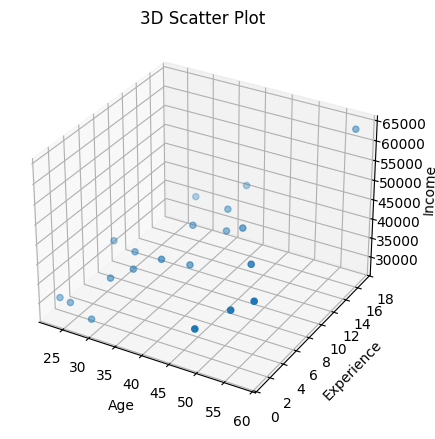

In [7]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['age'], df['experience'], df['income'])

ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('Income')
ax.set_title('3D Scatter Plot')

plt.show()

This follows a very clear linear trend, so let's try to regress on this data. But how???

Recall the closed form OLS regression formula: $(X^TX)^{-1}X^Ty$

> In our data each row is a datapoint. So the rows of our CSV are each datapoint: $X\in \mathbb{R}^{N\times 2}$

In [8]:
X = df[['age',	'experience']].to_numpy()
y = df['income'].to_numpy()
X

array([[25,  1],
       [30,  3],
       [47,  2],
       [32,  5],
       [43, 10],
       [51,  7],
       [28,  5],
       [33,  4],
       [37,  5],
       [39,  8],
       [29,  1],
       [47,  9],
       [54,  5],
       [51,  4],
       [44, 12],
       [41,  6],
       [58, 17],
       [23,  1],
       [44,  9],
       [37, 10]])

In [9]:
y

array([30450, 35670, 31580, 40130, 47830, 41630, 41340, 37650, 40250,
       45150, 27840, 46110, 36720, 34800, 51300, 38900, 63600, 30870,
       44190, 48700])

In [10]:
import numpy as np

# Add column of ones
X_with_intercept = np.c_[np.ones(X.shape[0]), X]

# Solve normal equation
beta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ (X_with_intercept.T @ y)

# Extract coefficients
beta_0 = beta[0]   # intercept
beta_1 = beta[1]
beta_2 = beta[2]

In [60]:
print(beta_0)
print(beta_1)
print(beta_2)

31261.68985410106
-99.19535546105271
2162.4041919241135


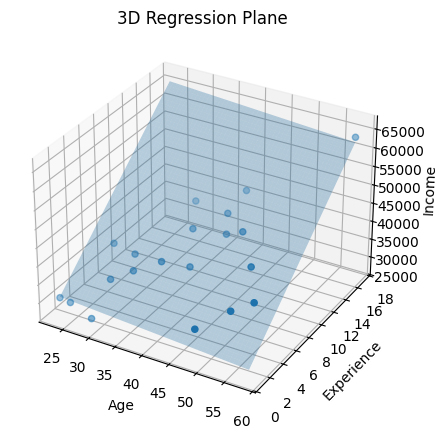

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(df['age'], df['experience'], df['income'])

# Create grid
age_range = np.linspace(df['age'].min(), df['age'].max(), 50)
exp_range = np.linspace(df['experience'].min(), df['experience'].max(), 50)

age_grid, exp_grid = np.meshgrid(age_range, exp_range)

# Compute predicted income (plane)
income_pred = beta_0 + beta_1 * age_grid + beta_2 * exp_grid

# Plot surface
ax.plot_surface(age_grid, exp_grid, income_pred, alpha=0.3)

ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('Income')
ax.set_title('3D Regression Plane')

plt.show()

## Do this with the MLE approach now

$\hat{w} = argmax_w \sum_{i=1}^n (x_i^Tw - y_i)^2$ and minimize this with SGD

In [69]:
(n, d) = X.shape
steps = 1000000
lr = 1e-6   # or tune this

# Add bias column
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

(n, d_aug) = X_aug.shape

w = np.random.rand(d_aug)

loss = []

for i in range(steps):
    idx = np.random.choice(n)
    x_i = X_aug[idx]
    y_i = y[idx]

    grad = 2 * (np.dot(x_i, w) - y_i) * x_i
    w -= lr * grad

    loss.append(np.mean((X_aug @ w - y) ** 2))

In [70]:
loss

[np.float64(1710112242.7355652),
 np.float64(1702270751.6607063),
 np.float64(1690364955.8821697),
 np.float64(1676502312.08572),
 np.float64(1663581176.3094232),
 np.float64(1650764129.2670927),
 np.float64(1639518054.3769891),
 np.float64(1634676298.4428458),
 np.float64(1622246188.748713),
 np.float64(1614337322.849198),
 np.float64(1599692614.4384756),
 np.float64(1592985135.330822),
 np.float64(1578530056.195375),
 np.float64(1570829059.0092463),
 np.float64(1557422931.1355622),
 np.float64(1552809656.5548253),
 np.float64(1544176278.5329216),
 np.float64(1531545011.1026845),
 np.float64(1520367614.2254357),
 np.float64(1507417861.2547626),
 np.float64(1495858294.0155087),
 np.float64(1489567635.2478647),
 np.float64(1483302346.9775221),
 np.float64(1472450662.64893),
 np.float64(1464923154.178386),
 np.float64(1456358806.7780294),
 np.float64(1446803667.5084596),
 np.float64(1442758328.5121493),
 np.float64(1438465855.3305671),
 np.float64(1426845325.9751627),
 np.float64(1422597

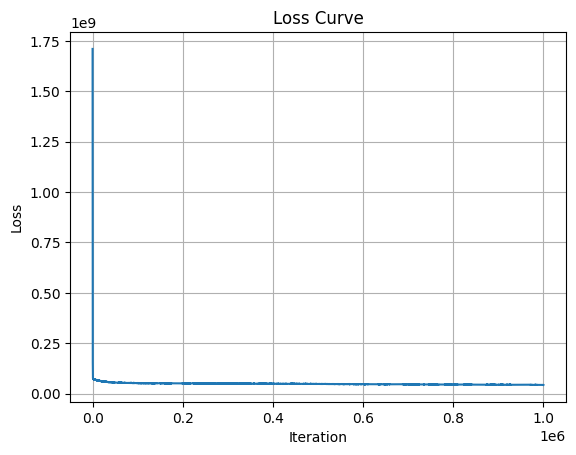

In [71]:
plt.figure()
plt.plot(loss)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.grid(True)
plt.show()

In [72]:
w

array([3123.23212683,  659.99837509, 1593.41568893])

In [ ]:
31261.68985410106
-99.19535546105271
2162.4041919241135

In [ ]:
loss[-1] # loss is still high

np.float64(43390104.736180164)